In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

In [10]:
# helper methods -------------------------------------------

def df_to_accuracy(frame):
    frame['correct'] = frame['true_label'] == frame['predicted_label']
    stats_df = frame.groupby('true_label')['correct'].mean()

    stats_df.loc['total'] = frame['correct'].mean()
    # print(stats_df)
    return stats_df

## manner of articulation
### data cleanup

go from predictions of individual records -> per-class, per-layer accuracy (for now) statistics

In [11]:
# load our predictions for manners of articulation
df_stats = pd.DataFrame(columns=['encoder', 'layer', 'class', 'accuracy'])

for i in range(12):
    # print("predictions/whisperMOA/layer" + str(i) + ".csv")
    layer_df = df_to_accuracy(pd.read_csv("predictions/whisperMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['whisper', i, class_name, accuracy]  

for i in range(12):
    layer_df = df_to_accuracy(pd.read_csv("predictions/wav2vecMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['wav2vec', i, class_name, accuracy]  

for i in range(32):
    layer_df = df_to_accuracy(pd.read_csv("predictions/voxtralMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['voxtral', i, class_name, accuracy]    

In [12]:
# normalizes
# ------------------------------------------------------- for each encoder,       get the max layer 
df_stats["layerNorm"] = df_stats["layer"] / df_stats.groupby("encoder")["layer"].transform("max")

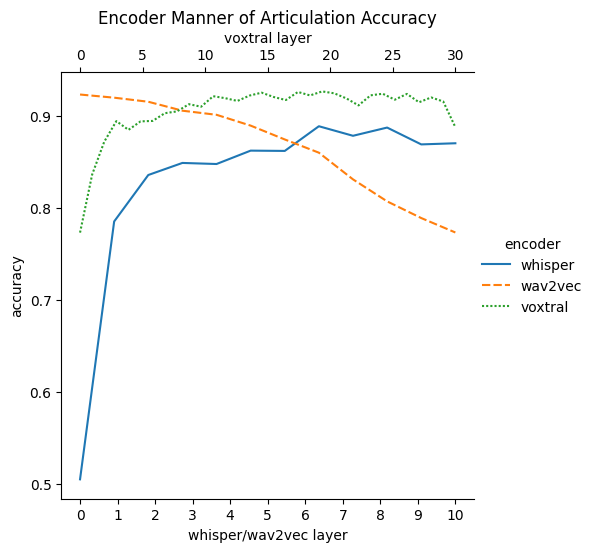

In [13]:
# print(df_stats)

fig = sns.relplot(
    data=df_stats[df_stats["class"] == "total"], kind="line",
    x="layerNorm", y="accuracy",
    hue="encoder", style="encoder",
    # height=3, aspect=1.6
)

ax = fig.ax

ax.set_xticks([i/10 for i in range(11)])
ax.set_xticklabels(i for i in range(11))
ax.set_xlabel("whisper/wav2vec layer")

top_ax = ax.secondary_xaxis("top", functions=(lambda x: x * 30, lambda x: x / 30))
top_ax.set_xticks(range(0, 31, 5))
top_ax.set_xlabel("voxtral layer")

ax.set_title("Encoder Manner of Articulation Accuracy")
plt.savefig("figures/layerwiseMoaAccuracy.png", bbox_inches="tight")

## phone
### the same thing, but again

In [14]:
# load our predictions for manners of articulation
df_stats = pd.DataFrame(columns=['encoder', 'layer', 'class', 'accuracy'])

for i in range(12):
    # print("predictions/whisperMOA/layer" + str(i) + ".csv")
    layer_df = df_to_accuracy(pd.read_csv("predictions/whisperPhone/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['whisper', i, class_name, accuracy]  

for i in range(12):
    layer_df = df_to_accuracy(pd.read_csv("predictions/wav2vecPhone/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['wav2vec', i, class_name, accuracy]  

for i in range(32):
    layer_df = df_to_accuracy(pd.read_csv("predictions/voxtralPhone/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['voxtral', i, class_name, accuracy]

In [15]:
# normalizes
# ------------------------------------------------------- for each encoder,       get the max layer 
df_stats["layerNorm"] = df_stats["layer"] / df_stats.groupby("encoder")["layer"].transform("max")

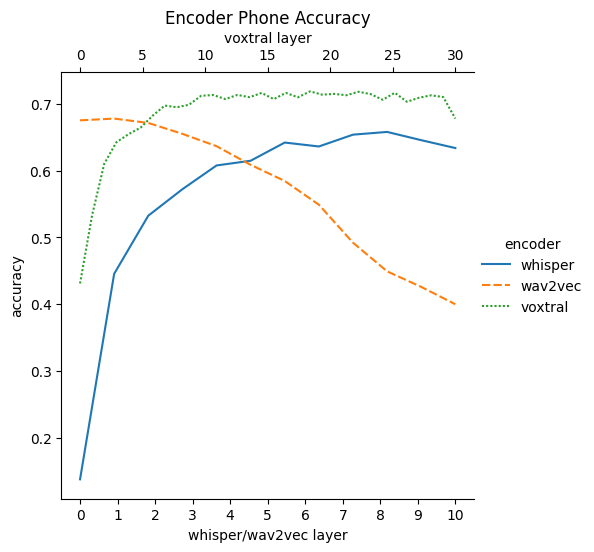

In [16]:
# print(df_stats)

fig = sns.relplot(
    data=df_stats[df_stats["class"] == "total"],
    kind="line",
    x="layerNorm", y="accuracy",
    hue="encoder", style="encoder",
    # height=3, aspect=1.6
)

ax = fig.ax

ax.set_xticks([i/10 for i in range(11)])
ax.set_xticklabels(i for i in range(11))
ax.set_xlabel("whisper/wav2vec layer")

top_ax = ax.secondary_xaxis("top", functions=(lambda x: x * 30, lambda x: x / 30))
top_ax.set_xticks(range(0, 31, 5))
top_ax.set_xlabel("voxtral layer")

ax.set_title("Encoder Phone Accuracy")
plt.savefig("figures/layerwisePhoneAccuracy.png", bbox_inches="tight")